# Chronos 2 Inference Pipeline
Use this file to test out different feature sets with Chronos-2.
Official documentation: https://github.com/amazon-science/chronos-forecasting

Run the following:
```
pip install 'chronos-forecasting>=2.0' 'pandas[pyarrow]' 'matplotlib' 'scikit-learn' 'numpy'
```


In [46]:
# Core
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Chronos - 2
from chronos import Chronos2Pipeline

In [47]:
# ============================
# User Config (EDIT ME)
# ============================

# CSV Loading
# Use forward slashes or escaped backslashes to avoid unicode-escape issues on Windows paths
csv_path = "data_UBS.csv"
date_col = "timestamp"
id_col = None #Set to column name if you have multiple series
default_id_value = "series_1" # Use this if id_col = None

# Target
target_col = "ctc_vol"

# Features
feature_cols = ["open_lag1","high_lag1", "close_lag1", "low_lag1"]

# Business Days reindexing
freq = "B"
reindex_start = None
reindex_end = None

# Train / Test split
split_start_date = "2020-01-01" # Train starts here
train_fraction = 0.80 # first 80% context, last 20% forecast horizon

# Chronos-2 model settings
device = "cpu" #if you can use a GPU, enter "cuda"


In [48]:
# ============================
# Load CSV and Basic Cleaing
# ============================

# load csv
df = pd.read_csv(csv_path)

# ensure datetime column is parsed correctly
df[date_col] = pd.to_datetime(df[date_col])

# Sort by time
df = df.sort_values(date_col).reset_index(drop=True)

# If there is no id column, create a single-id series
if id_col is None:
    df["id"] = default_id_value
    id_col = "id"


# Keep only needed columns
keep_cols = [id_col, date_col, target_col] + feature_cols
df = df[keep_cols].copy()

df.head()

,id,timestamp,ctc_vol,open_lag1,high_lag1,close_lag1,low_lag1
0,series_1,2015-03-13,0.011052,17.30,17.37,17.36,17.24
1,series_1,2015-03-16,0.012903,17.41,17.62,17.60,17.35
2,series_1,2015-03-17,0.011185,17.90,17.98,17.91,17.86
3,series_1,2015-03-18,0.012623,17.72,17.83,17.78,17.66
4,series_1,2015-03-19,0.015413,17.91,18.33,18.27,17.89


In [49]:
# ==========================================
# BUSINESS-DAY INDEX + REINDEXING (REQUIRED)
# (done per series to keep Chronos freq valid)
# ==========================================

value_cols = [target_col] + feature_cols

pieces = []

for sid, g in df.groupby(id_col):
    # Sort and remove duplicate timestamps (needed for stable frequency)
    g = g.sort_values(date_col).drop_duplicates(subset=[date_col])

    # Set timestamp index
    g = g.set_index(date_col)

    # Determine business-day range per series
    start_date = reindex_start if reindex_start is not None else g.index.min()
    end_date   = reindex_end   if reindex_end   is not None else g.index.max()
    bdays_idx = pd.date_range(start=start_date, end=end_date, freq=freq)

    # Reindex to business days -> may create NaNs
    g = g.reindex(bdays_idx)

    # Fill ONLY the NaNs created by reindexing
    # This keeps a fully regular business-day calendar.
    # Note!: Currently uses a simple Forward Fill - has to be changed as soon as a better solution is found.
    g[value_cols] = g[value_cols].ffill()

    # Restore id + timestamp column
    g[id_col] = sid
    g.index.name = date_col
    pieces.append(g.reset_index())

# Combine all series back together
df = pd.concat(pieces, ignore_index=True)

print(df.head(10))
print(df.tail(10))


   timestamp        id   ctc_vol  open_lag1  high_lag1  close_lag1  low_lag1
0 2015-03-13  series_1  0.011052      17.30    17.3700       17.36   17.2400
1 2015-03-16  series_1  0.012903      17.41    17.6200       17.60   17.3500
2 2015-03-17  series_1  0.011185      17.90    17.9800       17.91   17.8600
3 2015-03-18  series_1  0.012623      17.72    17.8300       17.78   17.6600
4 2015-03-19  series_1  0.015413      17.91    18.3300       18.27   17.8900
5 2015-03-20  series_1  0.018285      18.18    18.2601       18.14   18.1100
6 2015-03-23  series_1  0.018327      18.69    18.8400       18.70   18.5800
7 2015-03-24  series_1  0.015653      18.93    19.1000       19.04   18.9000
8 2015-03-25  series_1  0.016151      19.22    19.2983       19.14   19.1100
9 2015-03-26  series_1  0.014562      19.18    19.2600       19.02   18.9878
      timestamp        id   ctc_vol  open_lag1  high_lag1  close_lag1  \
2783 2025-11-12  series_1  0.009827      38.94    39.1350       38.98   
2784 20

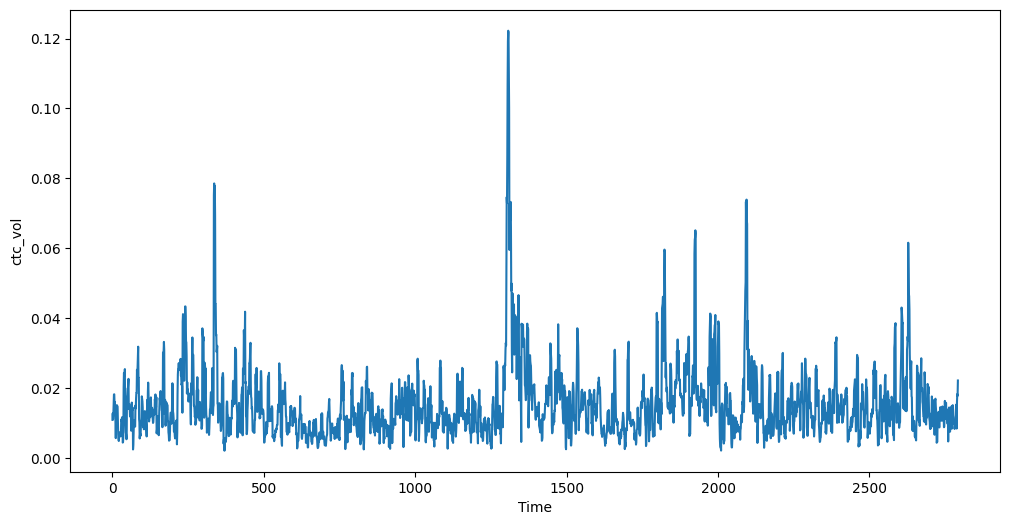

In [50]:
# Optional Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[target_col]) # Use df.index instead of df['Time']
plt.xlabel('Time')
plt.ylabel(target_col)
plt.show()

In [51]:
# ==========================================
# Define context_df + future_df
# ==========================================

# Make sure data is perfectly ordered before splitting
df = df.sort_values([id_col, date_col]).reset_index(drop=True)

# Filter dataset from split_start_date onwards
df_split = df[df[date_col] >= pd.Timestamp(split_start_date)]
df_split = df_split.sort_values(date_col).reset_index(drop=True)

# Compute split points
n_total = len(df_split)
n_train = int(np.floor(train_fraction * n_total))

context_df = df_split.iloc[:n_train].copy()
future_df = df_split.iloc[n_train:].copy()

# Show sizes
print("Context length:", len(context_df))
print("Future length :", len(future_df))
print("----- Context DF ----- ")
print(context_df.head())
print(context_df.tail())
print("----- Future DF ----- ")
print(future_df.head())
print(future_df.tail())

Context length: 1232
Future length : 308
----- Context DF ----- 
   timestamp        id   ctc_vol  open_lag1  high_lag1  close_lag1  low_lag1
0 2020-01-01  series_1  0.003097      12.61      12.63       12.58     12.58
1 2020-01-02  series_1  0.010795      12.54      12.59       12.58     12.50
2 2020-01-03  series_1  0.015462      12.70      12.92       12.92     12.67
3 2020-01-06  series_1  0.015694      12.68      12.77       12.71     12.65
4 2020-01-07  series_1  0.017593      12.60      12.70       12.68     12.58
      timestamp        id   ctc_vol  open_lag1  high_lag1  close_lag1  \
1227 2024-09-13  series_1  0.014196      28.86     29.095       28.98   
1228 2024-09-16  series_1  0.013139      29.38     29.665       29.59   
1229 2024-09-17  series_1  0.009300      29.65     29.830       29.79   
1230 2024-09-18  series_1  0.008876      30.00     30.050       29.76   
1231 2024-09-19  series_1  0.008831      29.91     30.320       29.91   

      low_lag1  
1227    28.680  


In [52]:
# ===========================
# Load Chronos-2 Model
# ===========================

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map = device,
)

#### Predict the full horizon in one go

In [43]:
# ======================================
# Build  Chronos and inference
# ======================================

"""
Chronos-2 can take two seperate dfs as inputs to perform forecasting. 
The context_df and the future_df. Only the context_df is mandatory.

The context_df includes:
- historical portion of data - including target, features, id, timestamp - that chronos uses to understand past behaviour and patterns.
- must include target
- can include past known covariates and features

The future_df includes:
- only timestamps and optional future-known covaraites for which predictions should be generated
- does NOT inlude the target
- typically represents the forecast horizon --> the part after the split
"""

# prediction length
pred_len = len(future_df)
if pred_len <= 0:
    raise ValueError("future_df is empty, no prediction possible.")

# Build columns sets for Chronos
# Note: in context_cols you have everything needed. in future_cols you just leave out the target_col
context_cols = [id_col, date_col, target_col] + feature_cols
future_cols = [id_col, date_col] + feature_cols

context_df_chronos = context_df[context_cols].reset_index(drop=True)
future_df_chronos = future_df[future_cols].reset_index(drop=True)

print(context_df_chronos.head())
print(future_df_chronos.head())

# Run Chronos inference
pred_df = pipeline.predict_df(
    context_df_chronos,
    #future_df = future_df_chronos,
    prediction_length= pred_len,
    quantile_levels = [0.1, 0.5, 0.9],
    id_column = id_col,
    timestamp_column = date_col,
    target = target_col
)

pred_df.head()


         id  timestamp   ctc_vol  open_lag1  high_lag1  close_lag1  low_lag1
0  series_1 2020-01-01  0.003097      12.61      12.63       12.58     12.58
1  series_1 2020-01-02  0.010795      12.54      12.59       12.58     12.50
2  series_1 2020-01-03  0.015462      12.70      12.92       12.92     12.67
3  series_1 2020-01-06  0.015694      12.68      12.77       12.71     12.65
4  series_1 2020-01-07  0.017593      12.60      12.70       12.68     12.58
         id  timestamp  open_lag1  high_lag1  close_lag1  low_lag1
0  series_1 2024-09-20      30.33     30.455       30.40   30.1000
1  series_1 2024-09-23      29.96     30.020       29.90   29.7050
2  series_1 2024-09-24      30.11     30.290       30.22   30.1000
3  series_1 2024-09-25      30.73     30.800       30.64   30.2913
4  series_1 2024-09-26      30.49     30.515       30.00   29.9800


c:\Users\Gil\SAI1\stonksAI\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,series_1,2024-09-20,ctc_vol,0.010059,0.006917,0.010059,0.014756
1,series_1,2024-09-23,ctc_vol,0.010288,0.006318,0.010288,0.016873
2,series_1,2024-09-24,ctc_vol,0.010636,0.005799,0.010636,0.018567
3,series_1,2024-09-25,ctc_vol,0.010907,0.005685,0.010907,0.019717
4,series_1,2024-09-26,ctc_vol,0.011315,0.005899,0.011315,0.021179


In [44]:
# ======================================
# Merge predictions with the true values
# ======================================

results = pred_df.merge(
    future_df[[id_col, date_col, target_col]],
    on=[id_col, date_col],
    how="left"
)

y_true = results[target_col].astype(float)
y_pred_median = results["0.5"].astype(float)

results.head()


,id,timestamp,target_name,predictions,0.1,0.5,0.9,ctc_vol
0,series_1,2024-09-20,ctc_vol,0.010059,0.006917,0.010059,0.014756,0.012135
1,series_1,2024-09-23,ctc_vol,0.010288,0.006318,0.010288,0.016873,0.012626
2,series_1,2024-09-24,ctc_vol,0.010636,0.005799,0.010636,0.018567,0.013213
3,series_1,2024-09-25,ctc_vol,0.010907,0.005685,0.010907,0.019717,0.017935
4,series_1,2024-09-26,ctc_vol,0.011315,0.005899,0.011315,0.021179,0.022594


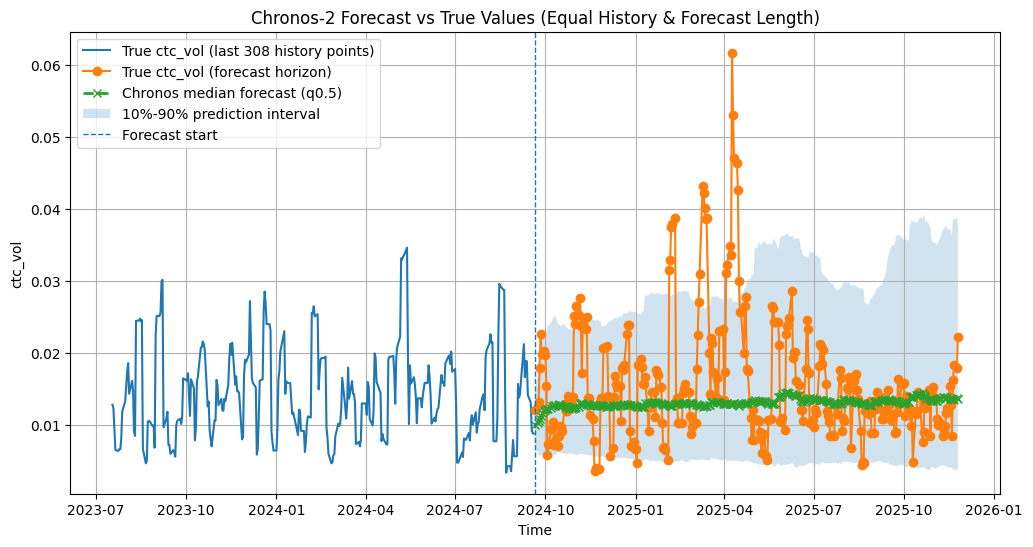

In [45]:
# ===========================
# Plot
# ===========================

# How many steps were predicted
pred_len = len(results)

# Take exactly the last pred_len historical points
hist_part = context_df[[date_col, target_col]].copy()
hist_part = hist_part.sort_values(date_col).tail(pred_len)

# True future (for the forecast horizon)
true_future_part = future_df[[date_col, target_col]].copy()
true_future_part = true_future_part.sort_values(date_col).head(pred_len)

# Forecast (median + optional intervals)
forecast_part = results[[date_col, "0.5"]].copy().sort_values(date_col)

plt.figure(figsize=(12, 6))

# Plot historical true (same length as forecast)
plt.plot(
    hist_part[date_col],
    hist_part[target_col].astype(float),
    label=f"True {target_col} (last {pred_len} history points)",
    linewidth=1.5
)

# Plot true future values
plt.plot(
    true_future_part[date_col],
    true_future_part[target_col].astype(float),
    label=f"True {target_col} (forecast horizon)",
    linewidth=1.5,
    marker="o"
)

# Plot median forecast
plt.plot(
    forecast_part[date_col],
    forecast_part["0.5"].astype(float),
    label="Chronos median forecast (q0.5)",
    linestyle="--",
    linewidth=2,
    marker="x"
)

# Optional uncertainty band if available
if "0.1" in results.columns and "0.9" in results.columns:
    plt.fill_between(
        results[date_col],
        results["0.1"].astype(float),
        results["0.9"].astype(float),
        alpha=0.2,
        label="10%-90% prediction interval"
    )

# Vertical line at forecast start
split_ts = true_future_part[date_col].min()
plt.axvline(split_ts, linestyle="--", linewidth=1, label="Forecast start")

plt.title("Chronos-2 Forecast vs True Values (Equal History & Forecast Length)")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()


In [48]:
# ===========================
# Metrics
# ===========================

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred_median))

# MAE
mae = mean_absolute_error(y_true, y_pred_median)

# Adjusted R Squared
r2 = r2_score(y_true, y_pred_median)
n = len(y_true)
p = len(feature_cols)

if n - p - 1 > 0:
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adj_r2 = np.nan  # not defined if too few samples vs features

# Quantile Loss (Pinball loss)
valid_mask = ~y_true.isna()
def pinball_loss(y, yhat, q):
    diff = y - yhat
    return np.mean(np.maximum(q * diff, (q - 1)* diff))

quantile_losses = {}
for q in [0.1, 0.5, 0.9]:
    q_str = str(q)
    yhat_q = results[q_str].astype(float)[valid_mask]
    quantile_losses[q] = pinball_loss(y_true.values, yhat_q.values, q)

# CRPS approximation
qs = np.array(sorted(quantile_losses.keys()))
Ls = np.array([quantile_losses[q] for q in qs])
crps = 2 * np.trapezoid(Ls, qs)

# Print
print("CRPS (approx.):", crps)
print("RMSE:", rmse)
print("MAE:", mae)
print("Adjusted R^2:", adj_r2)
print("Quantile Losses:")
for q, Lq in quantile_losses.items():
    print(f"--> q={q}: {Lq}")


CRPS (approx.): 0.20652661013912843
RMSE: 0.4869427392711228
MAE: 0.36335281241280687
Adjusted R^2: 0.982623733210049
Quantile Losses:
--> q=0.1: 0.08499453517765192
--> q=0.5: 0.18167640620640343
--> q=0.9: 0.06796917775736225


### More realistic approach - Rolling backtest
You only predict the next day. You repeat that until you have predicted the whole prediction horizon.

In [ ]:
# ==========================================
# Rolling Backtest: 1-Schritt-Vorhersage
# ==========================================

"""
Idee:
- Wir simulieren, dass wir jeden Tag nur die Daten bis gestern kennen.
- Wir starten mit dem ursprünglichen context_df.
- Für jeden Tag im future_df:
    - Kontext = context_df + alle bisher schon beobachteten "Future"-Tage (mit echten Targets)
    - Wir rufen Chronos mit prediction_length=1 und OHNE future_df auf.
    - Wir speichern die 1-Schritt-Vorhersage und gehen einen Tag weiter.
"""

# Sicherstellen, dass context_df und future_df existieren
assert 'context_df' in globals(), "context_df ist nicht definiert. Bitte zuerst die Split-Zelle ausführen."
assert 'future_df' in globals(), "future_df ist nicht definiert. Bitte zuerst die Split-Zelle ausführen."

# Zusammenbau von Train + Test (nur zur sauberen Zeit-Reihenfolge)
df_roll = pd.concat([context_df, future_df], ignore_index=True)
df_roll = df_roll.sort_values(date_col).reset_index(drop=True)

initial_context_len = len(context_df)
horizon_len = len(future_df)

print(f"Initiale Kontext-Länge: {initial_context_len}")
print(f"Rolling-Horizont (Anzahl Tage im future_df): {horizon_len}")

rolling_pred_list = []

for step in range(horizon_len):
    
    # Kontext: alle Daten bis einschließlich Tag t-1
    end_idx = initial_context_len + step  # slicing ist exklusiv, also bis end_idx-1
    context_step = df_roll.iloc[:end_idx].copy()
    
    # Für Chronos: gleiche Spalten wie bei deiner normalen Inferenz
    context_step_chronos = context_step[[id_col, date_col, target_col] + feature_cols].reset_index(drop=True)

    # 1-Schritt-Vorhersage ohne future_df
    step_pred_df = pipeline.predict_df(
        context_step_chronos,
        prediction_length = 1,
        quantile_levels   = [0.1, 0.5, 0.9],
        id_column         = id_col,
        timestamp_column  = date_col,
        target            = target_col
    )
    
    # Schritt speichern
    rolling_pred_list.append(step_pred_df)
    
    # Optional: Fortschritt anzeigen
    if (step + 1) % 10 == 0 or step == horizon_len - 1:
        print(f"Rolling Step {step + 1}/{horizon_len} fertig.")

# Alle 1-Schritt-Predictions hintereinander
rolling_pred_df = pd.concat(rolling_pred_list, ignore_index=True)

print("Rolling-Predictions (nur Vorhersagen):")
print(rolling_pred_df.head())
print(rolling_pred_df.tail())

# Nun joinen wir – analog zu deiner normalen Pipeline – die echten Werte aus future_df hinzu
results_rolling = rolling_pred_df.merge(
    future_df[[id_col, date_col, target_col]],
    on=[id_col, date_col],
    how="left"
)

# y_true und Median-Prediction für Rolling-Backtest
y_true_rolling = results_rolling[target_col].astype(float)
y_pred_median_rolling = results_rolling["0.5"].astype(float)

print("Rolling-Ergebnis (mit True-Werten):")
print(results_rolling.head())
print(results_rolling.tail())


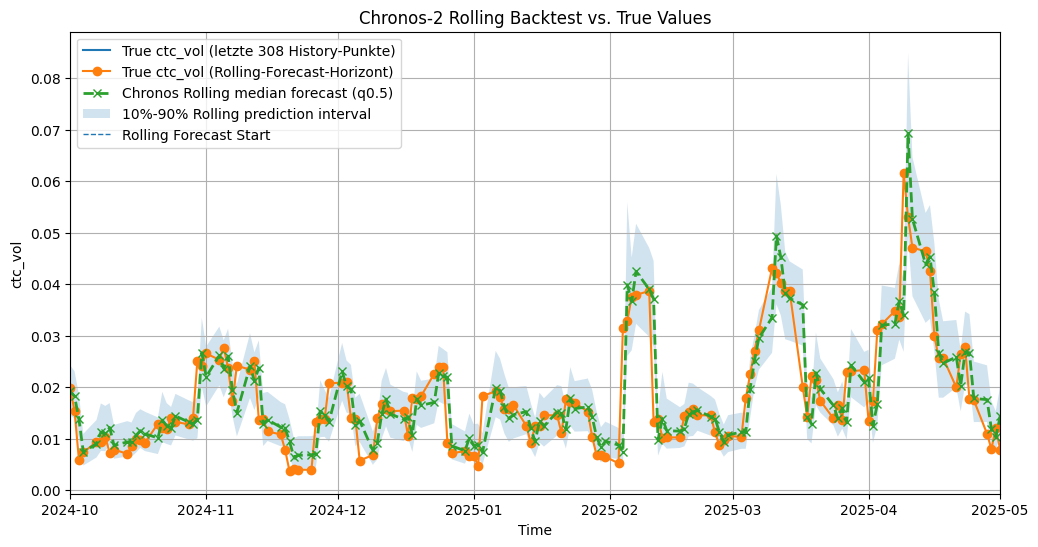

In [54]:
# ===========================
# Plot: Rolling Backtest
# ===========================

# Wie viele Schritte gibt es im Rolling-Backtest?
pred_len_roll = len(results_rolling)

# Historische Daten (gleiche Länge wie Forecast-Horizont)
hist_part_roll = context_df[[date_col, target_col]].copy()
hist_part_roll = hist_part_roll.sort_values(date_col).tail(pred_len_roll)

# True future (ganzer Forecast-Horizont)
true_future_part_roll = future_df[[date_col, target_col]].copy()
true_future_part_roll = true_future_part_roll.sort_values(date_col).head(pred_len_roll)

# Rolling Forecast (Median + optional Intervalle)
forecast_part_roll = results_rolling[[date_col, "0.5"]].copy().sort_values(date_col)

plt.figure(figsize=(12, 6))

# Plot historischer Verlauf (gleiche Länge wie Forecast)
plt.plot(
    hist_part_roll[date_col],
    hist_part_roll[target_col].astype(float),
    label=f"True {target_col} (letzte {pred_len_roll} History-Punkte)",
    linewidth=1.5
)

# Plot true future values
plt.plot(
    true_future_part_roll[date_col],
    true_future_part_roll[target_col].astype(float),
    label=f"True {target_col} (Rolling-Forecast-Horizont)",
    linewidth=1.5,
    marker="o"
)

# Plot Rolling median forecast
plt.plot(
    forecast_part_roll[date_col],
    forecast_part_roll["0.5"].astype(float),
    label="Chronos Rolling median forecast (q0.5)",
    linestyle="--",
    linewidth=2,
    marker="x"
)

# Optional Band, falls Quantile vorhanden
if "0.1" in results_rolling.columns and "0.9" in results_rolling.columns:
    plt.fill_between(
        results_rolling[date_col],
        results_rolling["0.1"].astype(float),
        results_rolling["0.9"].astype(float),
        alpha=0.2,
        label="10%-90% Rolling prediction interval"
    )

# Vertikale Linie am Start des Forecast-Horizonts
split_ts_roll = true_future_part_roll[date_col].min()
plt.axvline(split_ts_roll, linestyle="--", linewidth=1, label="Rolling Forecast Start")

plt.title("Chronos-2 Rolling Backtest vs. True Values")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.xlim(pd.Timestamp("2024-10-01"), pd.Timestamp("2025-05-01"))
plt.show()


In [55]:
# ===========================
# Metrics – Rolling Backtest
# ===========================

# RMSE
rmse_rolling = np.sqrt(mean_squared_error(y_true_rolling, y_pred_median_rolling))

# MAE
mae_rolling = mean_absolute_error(y_true_rolling, y_pred_median_rolling)

# Adjusted R Squared
r2_rolling = r2_score(y_true_rolling, y_pred_median_rolling)
n_roll = len(y_true_rolling)
p_roll = len(feature_cols)

if n_roll - p_roll - 1 > 0:
    adj_r2_rolling = 1 - (1 - r2_rolling) * (n_roll - 1) / (n_roll - p_roll - 1)
else:
    adj_r2_rolling = np.nan  # nicht definiert bei zu wenig Samples vs. Features

# Quantile Loss (Pinball loss)
valid_mask_roll = ~y_true_rolling.isna()

def pinball_loss(y, yhat, q):
    diff = y - yhat
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

quantile_losses_rolling = {}
for q in [0.1, 0.5, 0.9]:
    q_str = str(q)
    yhat_q_roll = results_rolling[q_str].astype(float)[valid_mask_roll]
    quantile_losses_rolling[q] = pinball_loss(y_true_rolling.values, yhat_q_roll.values, q)

# CRPS-Approximation
qs_roll = np.array(sorted(quantile_losses_rolling.keys()))
Ls_roll = np.array([quantile_losses_rolling[q] for q in qs_roll])
crps_rolling = 2 * np.trapezoid(Ls_roll, qs_roll)

# Ausgabe
print("== Rolling Backtest Metrics ==")
print("CRPS (approx., rolling):", crps_rolling)
print("RMSE (rolling):", rmse_rolling)
print("MAE (rolling):", mae_rolling)
print("Adjusted R^2 (rolling):", adj_r2_rolling)
print("Quantile Losses (rolling):")
for q, Lq in quantile_losses_rolling.items():
    print(f"--> q={q}: {Lq}")


== Rolling Backtest Metrics ==
CRPS (approx., rolling): 0.001925167265076241
RMSE (rolling): 0.004736887868661249
MAE (rolling): 0.003118947152023463
Adjusted R^2 (rolling): 0.6867568048909942
Quantile Losses (rolling):
--> q=0.1: 0.0007070684133287585
--> q=0.5: 0.0015594735760117316
--> q=0.9: 0.0009869025973383808
